Literature Review
--
Customer churn is one of the major challenges in the e-commerce industry because retaining existing customers is more cost-effective than acquiring new ones. Many researchers have studied customer behavior patterns to identify factors that influence customer retention and churn.

Previous studies show that variables such as customer engagement, satisfaction score, loyalty membership, purchase frequency, cart abandonment rate, and customer support experience significantly affect customer retention. Customers with high engagement and satisfaction levels are more likely to remain loyal to an e-commerce platform, while inactive customers with low engagement and high cart abandonment rates show a higher probability of churn.

Researchers also found that loyalty programs positively impact customer spending behavior and improve long-term customer relationships. Similarly, product review scores and customer feedback are considered important indicators of customer satisfaction and purchase intention.

Several studies have used Exploratory Data Analysis (EDA) and machine learning techniques such as Logistic Regression, Decision Trees, Random Forest, and XGBoost to analyze customer behavior and predict churn. These techniques help businesses identify at-risk customers and improve retention strategies.

Overall, the literature suggests that analyzing customer behavior data can help e-commerce companies improve customer satisfaction, reduce churn, and increase profitability through better business decisions and personalized customer experiences.


## Objective of EDA

The main objective of this Exploratory Data Analysis (EDA) is to understand customer behavior patterns, identify factors affecting customer churn, and discover meaningful relationships between variables to support better business decisions and customer retention strategies.

## Target Variable

The target variable in this dataset is **`churned`**, which indicates whether a customer has left the platform or remained active.


In [1]:
#  Imports libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#  Loading dataset
df = pd.read_csv('e commerce.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (6000, 16)

First 5 rows:


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [5]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


In [6]:
# For checking features/columns 
print("Features/Columns:")
print(df.columns)

Features/Columns:
Index(['Customer_ID', 'account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'loyalty_member',
       'browsing_frequency_per_week', 'cart_abandonment_rate',
       'product_review_score_avg', 'engagement_score', 'satisfaction_score',
       'price_sensitivity_index', 'churned'],
      dtype='object')


In [7]:
# Check total duplicate rows
df.duplicated().sum()

np.int64(0)

There are some outlier present in the dataset but not need to remove
--
b/c

“The outliers were not removed from the dataset because they represent genuine customer behavior patterns such as high spending customers, frequent buyers, and inactive users. These extreme values provide important business insights and are useful for understanding customer behavior, customer retention, and churn prediction.”


Univariate Analysis
--

Churn Distribution
--

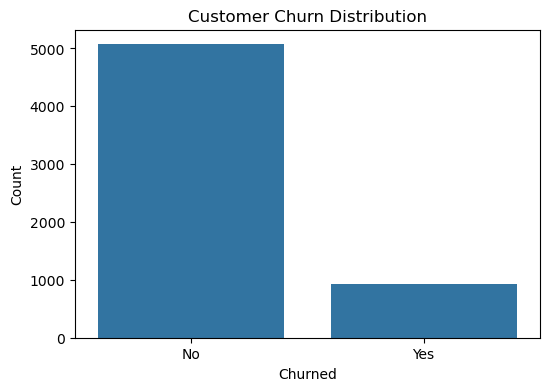

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='churned')

plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')

plt.show()

### What the Graph Shows:

- The graph shows the number of churned and active customers.
- Helps understand class balance in the dataset.
- If churned customers are fewer, the dataset may be imbalanced.
- Important for churn prediction analysis.

### Engagement Score Distribution

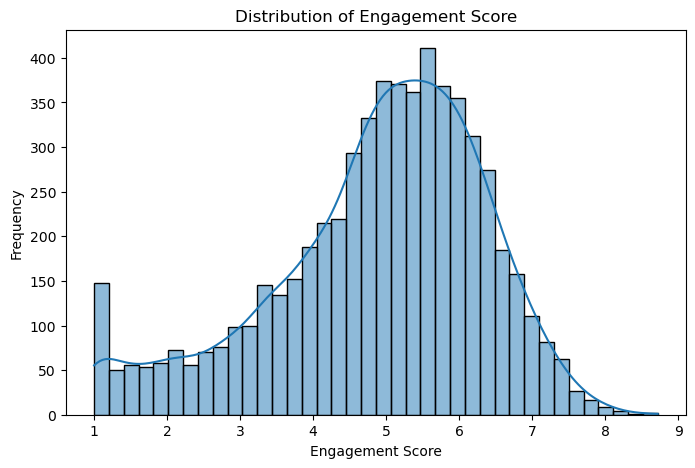

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['engagement_score'], kde=True)

plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')

plt.show()

### What the Graph Shows
- The graph shows how customer engagement is distributed.
- Higher engagement usually indicates loyal customers.
- Low engagement customers may have higher churn risk.
- Helps identify overall customer activity behavior.

### Satisfaction Score Distribution

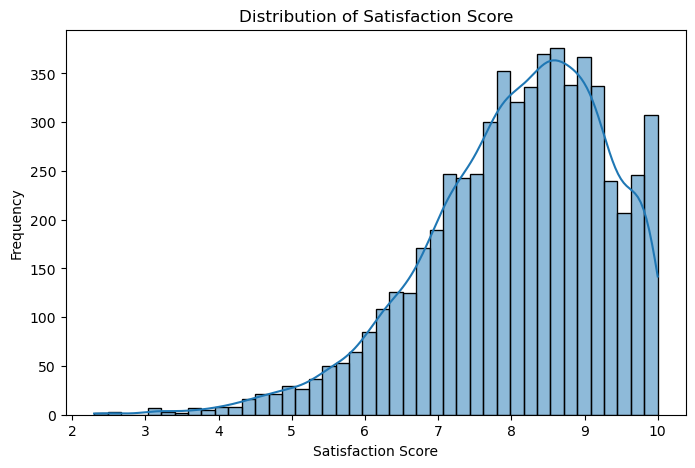

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['satisfaction_score'], kde=True)

plt.title('Distribution of Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')

plt.show()

What the Graph Shows
--
- The graph shows customer satisfaction levels.
- Customers with lower satisfaction scores are more likely to churn.
- High satisfaction indicates positive customer experience.
- Useful for understanding retention behavior.

Days Since Last Purchase Distribution
--

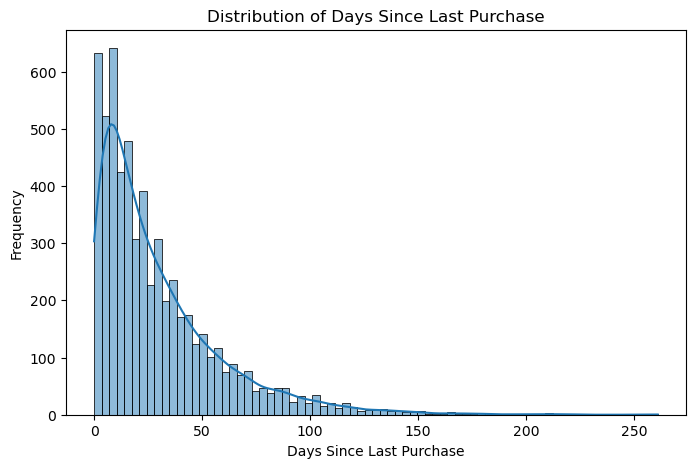

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['days_since_last_purchase'], kde=True)

plt.title('Distribution of Days Since Last Purchase')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Frequency')

plt.show()

What the Graph Shows
- The graph shows customer inactivity periods.
- Customers with very high inactivity may churn soon.
- Most active customers usually have lower recency values.
- Important churn indicator.

Cart Abandonment Rate Distribution
-

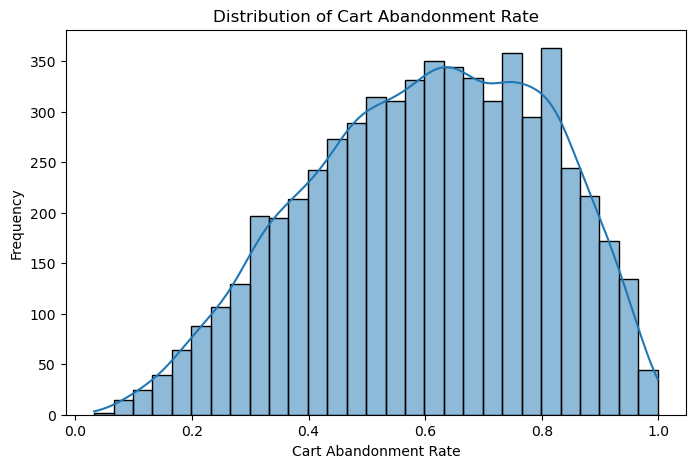

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['cart_abandonment_rate'], kde=True)

plt.title('Distribution of Cart Abandonment Rate')
plt.xlabel('Cart Abandonment Rate')
plt.ylabel('Frequency')

plt.show()

What the Graph Shows

- The graph shows how frequently customers abandon carts.
- Higher abandonment rates may indicate purchase hesitation.
- Customers with high abandonment behavior may have higher churn probability.
- Important behavioral metric in e-commerce analysis.

 Loyalty Membership Distribution
- 

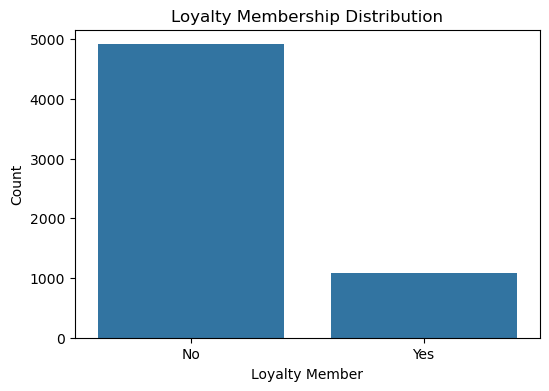

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='loyalty_member')

plt.title('Loyalty Membership Distribution')
plt.xlabel('Loyalty Member')
plt.ylabel('Count')

plt.show()

What the Graph Shows

- The graph shows the number of loyalty and non-loyalty customers.
- Loyalty customers are generally more engaged and retained.
- Helps understand customer retention strategies.
- Useful for analyzing loyalty program impact.

Customer Support Tickets Distribution
-

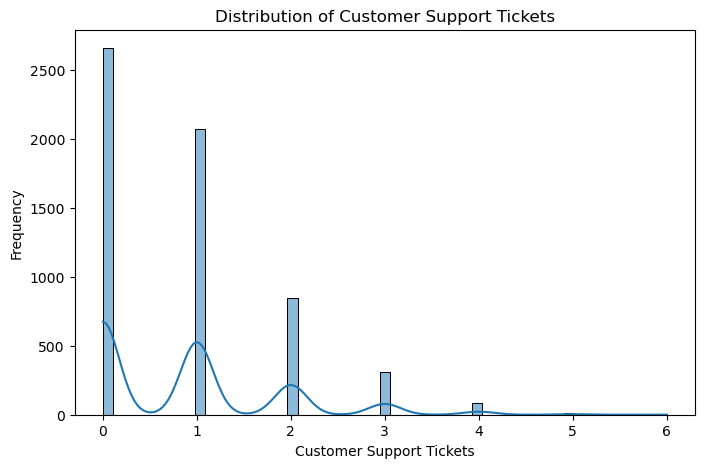

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['customer_support_tickets'], kde=True)

plt.title('Distribution of Customer Support Tickets')
plt.xlabel('Customer Support Tickets')
plt.ylabel('Frequency')

plt.show()

What the Graph Shows

- The graph shows the frequency of customer complaints/issues.
- Customers with many support tickets may have poor experience.
- High complaint frequency may increase churn probability.
- Helps evaluate customer service quality.

Avg Order Value Distribution
-

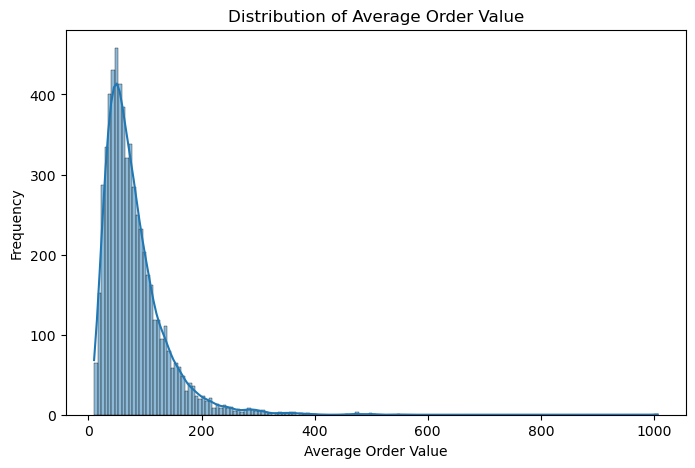

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['avg_order_value'], kde=True)

plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Frequency')

plt.show()

What the Graph Shows

- The graph shows customer spending behavior.
- Most customers fall within lower to medium spending ranges.
- A few high-spending customers appear as outliers.
- Important for identifying valuable customers.

E-Commerce Dataset — Bivariate Analysis
--
Objective
-
The purpose of this bivariate analysis is to understand the relationship between two variables and identify customer behavior patterns related to churn, spending, engagement, loyalty, and satisfaction.

 Avg Order Value vs Total Orders
   --

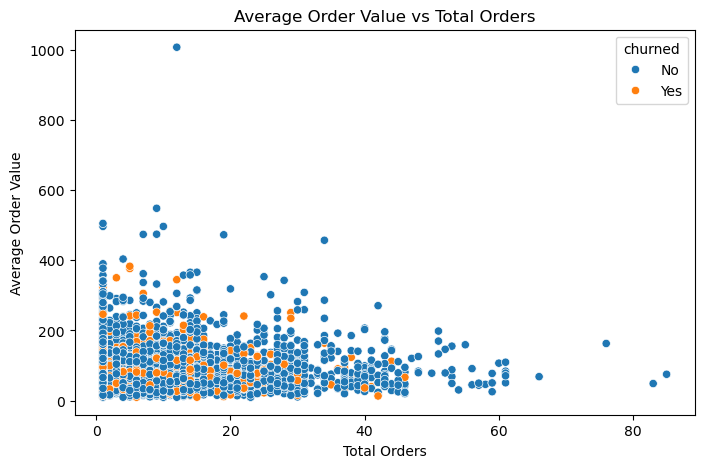

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='total_orders', y='avg_order_value', hue='churned')
plt.title('Average Order Value vs Total Orders')
plt.xlabel('Total Orders')
plt.ylabel('Average Order Value')
plt.show()

## Observation
- Customers with higher total orders generally show higher average order values.
- Some customers have very high spending behavior, visible as outliers.
- Churned customers are more concentrated in the lower-order region.
- Loyal purchasing behavior appears connected with customer retention.

## Satisfaction Score vs Engagement Score

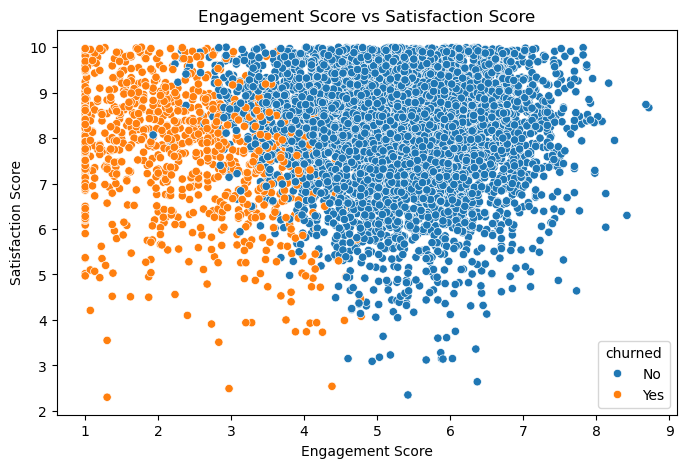

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='engagement_score', y='satisfaction_score', hue='churned')
plt.title('Engagement Score vs Satisfaction Score')
plt.xlabel('Engagement Score')
plt.ylabel('Satisfaction Score')
plt.show()

Observation
--
- A positive relationship is visible between engagement and satisfaction.
- Customers with low engagement scores tend to show lower satisfaction.
- Most churned customers appear in the low engagement and low satisfaction area.
- Highly engaged customers are less likely to churn.

Days Since Last Purchase vs Churn
--

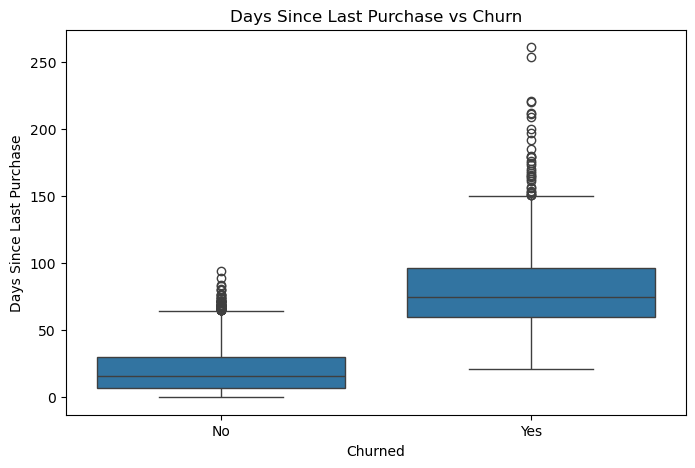

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='churned', y='days_since_last_purchase')

plt.title('Days Since Last Purchase vs Churn')
plt.xlabel('Churned')
plt.ylabel('Days Since Last Purchase')

plt.show()

## Graph Shows
Churned customers have higher days since last purchase. Active customers purchase more frequently.
Larger inactivity periods indicate higher churn risk. The graph clearly shows that inactive customers are more likely to leave the platform.

Cart Abandonment Rate vs Churn
--

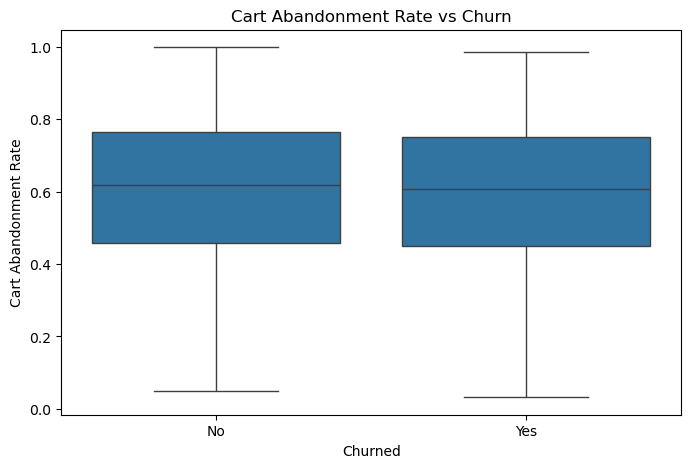

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churned',
    y='cart_abandonment_rate'
)

plt.title('Cart Abandonment Rate vs Churn')
plt.xlabel('Churned')
plt.ylabel('Cart Abandonment Rate')

plt.show()

Churned customers generally have higher cart abandonment rates.
Customers leaving products in carts frequently are more likely to churn.
Lower cart abandonment is associated with better customer retention.
The graph indicates customer purchase hesitation behavior.

 Loyalty Membership vs Average Order Value
--

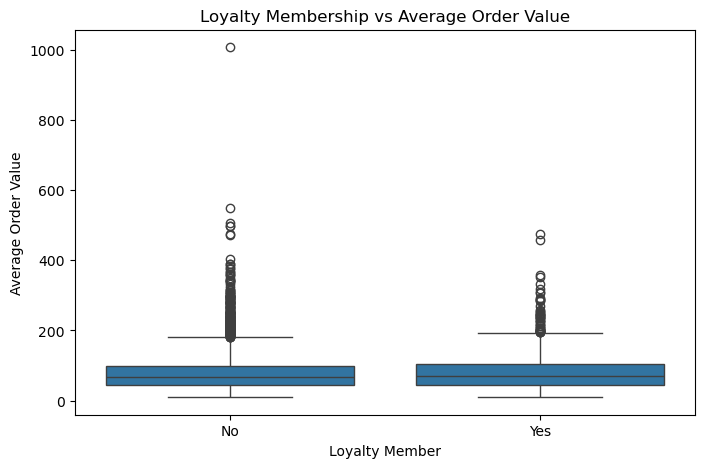

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='loyalty_member',
    y='avg_order_value'
)

plt.title('Loyalty Membership vs Average Order Value')
plt.xlabel('Loyalty Member')
plt.ylabel('Average Order Value')

plt.show()

Loyalty members spend more on average compared to non-members.
The median order value is higher for loyalty customers.
Loyalty programs positively influence customer spending behavior.
The graph suggests that loyalty membership improves customer retention and revenue.

Customer Support Tickets vs Satisfaction Score
--

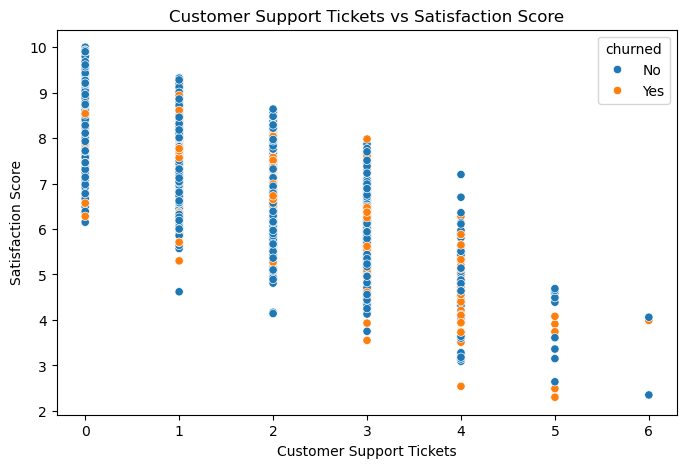

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='customer_support_tickets',
    y='satisfaction_score',
    hue='churned'
)

plt.title('Customer Support Tickets vs Satisfaction Score')
plt.xlabel('Customer Support Tickets')
plt.ylabel('Satisfaction Score')

plt.show()

Customers with more support tickets generally have lower satisfaction scores.
Churned customers are more common among users with frequent complaints.
Poor customer service experience negatively affects customer retention.
The graph highlights the importance of effective customer support.

Multivariate Analysis
-

### Correlation Heatmap


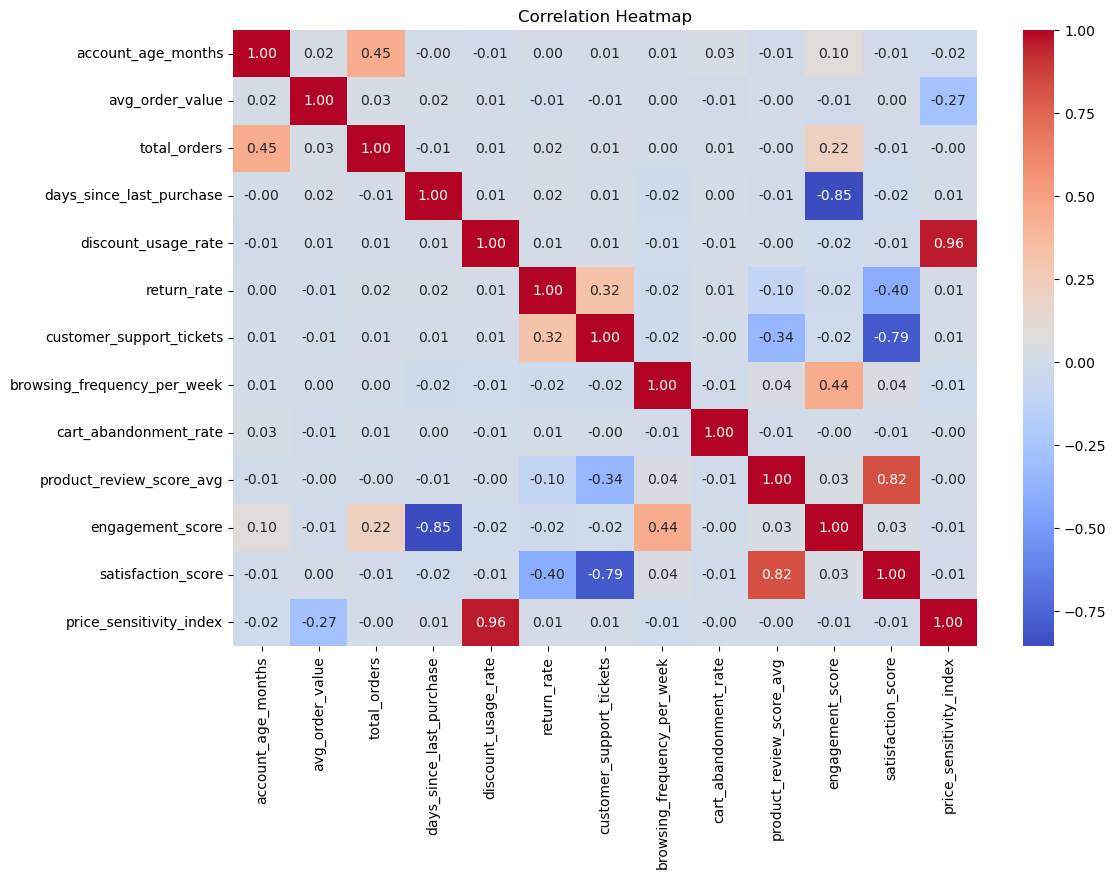

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

What the Graph Shows

- The graph shows relationships among multiple numerical variables together.
- Positive correlation means both variables increase together.
- Negative correlation means one variable increases while the other decreases.
- Engagement score and satisfaction score show strong positive relationship.
- Days since last purchase negatively affects engagement and retention.
- Helps identify variables that influence churn behavior.

Pairplot for Important Variables
-

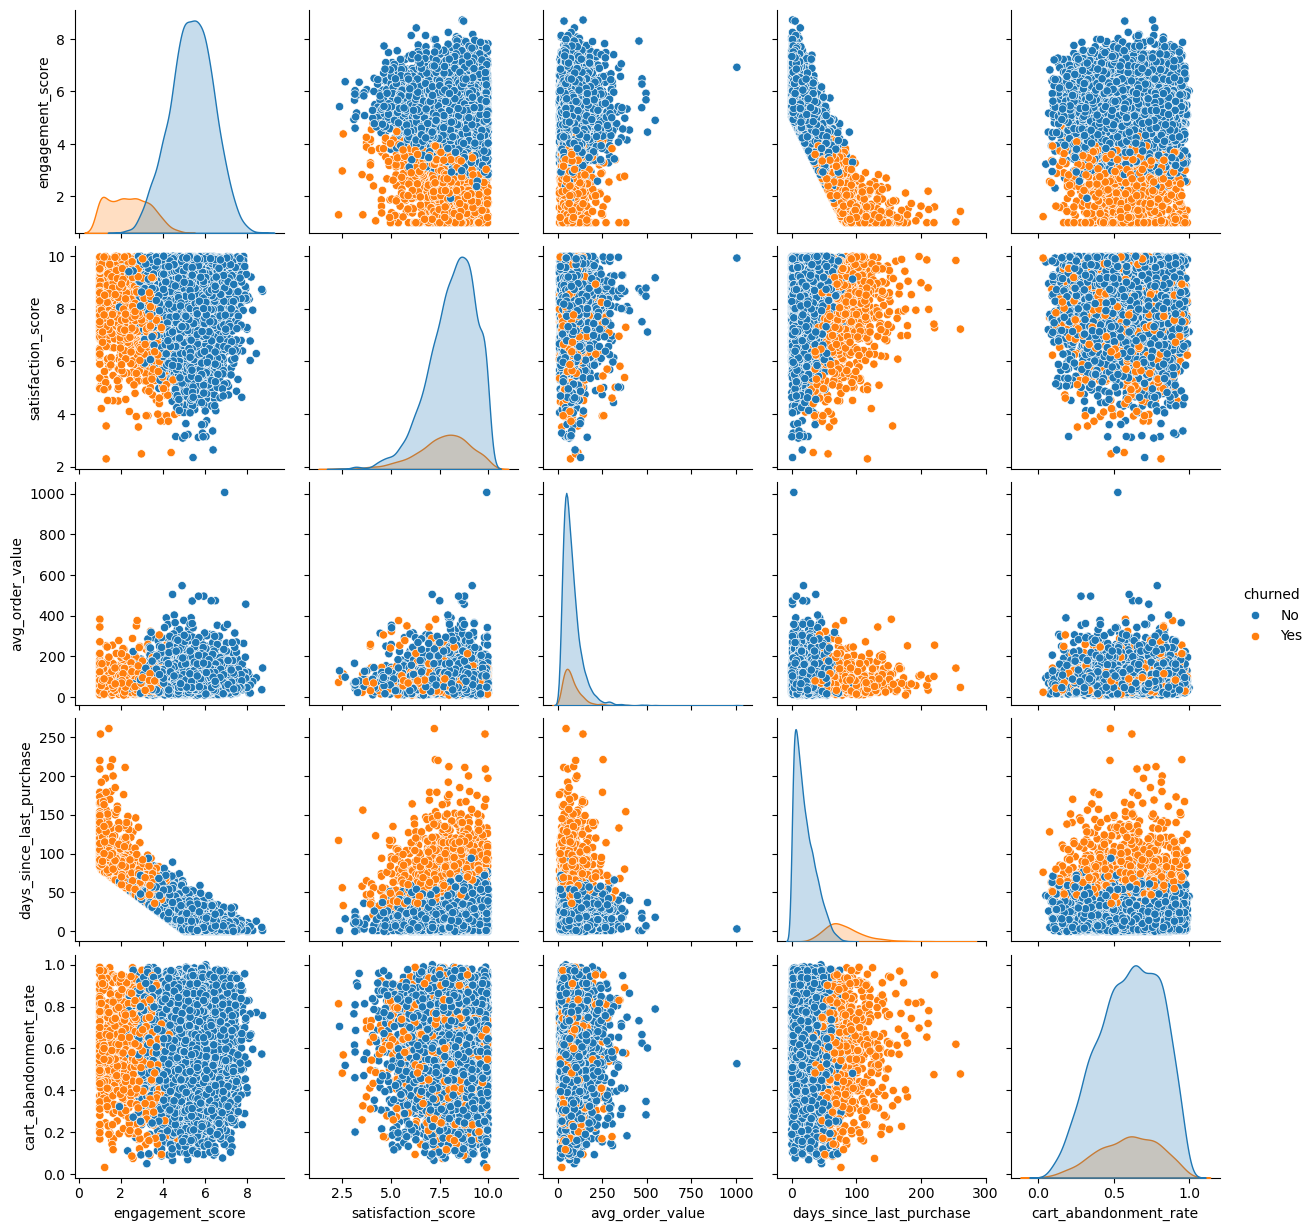

In [27]:
important_cols = [
    'engagement_score',
    'satisfaction_score',
    'avg_order_value',
    'days_since_last_purchase',
    'cart_abandonment_rate',
    'churned'
]

sns.pairplot(
    df[important_cols],
    hue='churned'
)

plt.show()

What the Graph Shows

- The graph compares multiple variables simultaneously.
- It shows distribution and relationships between important features.
- Churned customers mostly appear in:
  - low engagement
  - low satisfaction
  - high inactivity
  - high cart abandonment
- Helps identify behavioral differences between churned and retained customers.


### 3. Engagement + Satisfaction + Churn

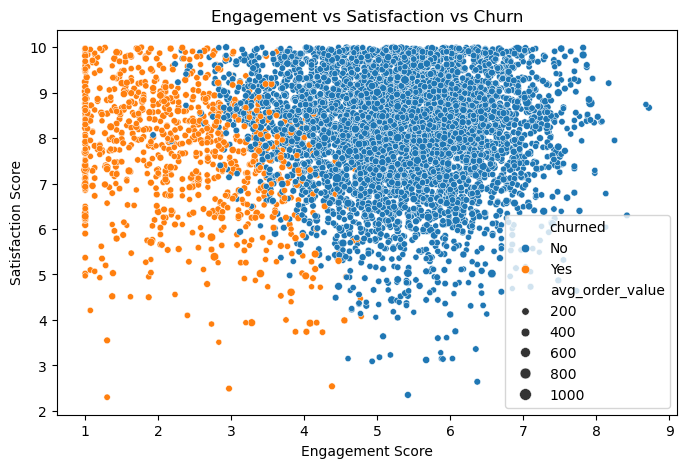

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='engagement_score',
    y='satisfaction_score',
    size='avg_order_value',
    hue='churned'
)

plt.title('Engagement vs Satisfaction vs Churn')
plt.xlabel('Engagement Score')
plt.ylabel('Satisfaction Score')

plt.show()

What the Graph Shows

- Highly engaged and satisfied customers are mostly retained.
- Churned customers appear in low engagement and low satisfaction areas.
- Larger points represent customers with higher order values.
- The graph combines spending behavior, satisfaction, engagement, and churn together.

Cart Abandonment + Inactivity + Churn
-

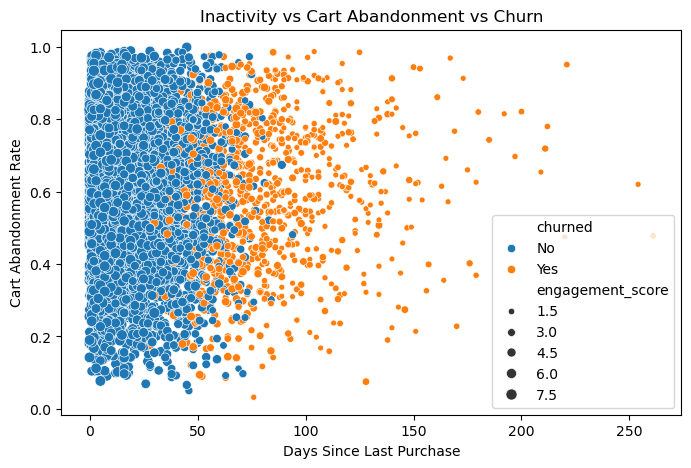

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='days_since_last_purchase',
    y='cart_abandonment_rate',
    hue='churned',
    size='engagement_score'
)

plt.title('Inactivity vs Cart Abandonment vs Churn')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Cart Abandonment Rate')

plt.show()

What the Graph Shows

- Customers with high inactivity and high cart abandonment are more likely to churn.
- Small-size points indicate low engagement customers.
- Active customers generally show lower abandonment behavior.
- The graph helps identify high-risk customers.

. Loyalty + Spending + Satisfaction
-

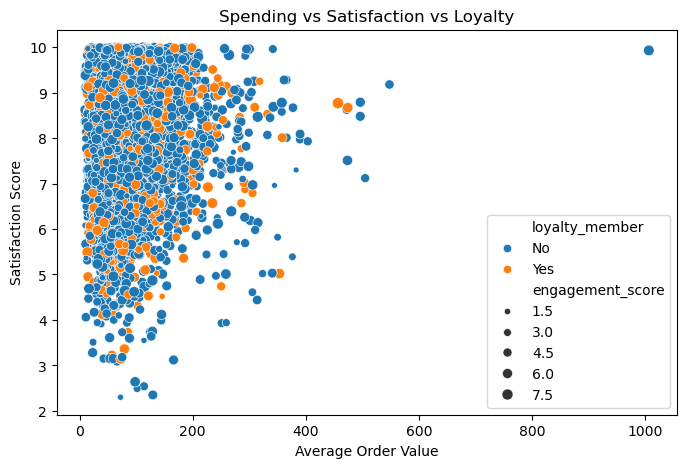

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='avg_order_value',
    y='satisfaction_score',
    hue='loyalty_member',
    size='engagement_score'
)

plt.title('Spending vs Satisfaction vs Loyalty')
plt.xlabel('Average Order Value')
plt.ylabel('Satisfaction Score')

plt.show()

What the Graph Shows

- Loyalty members generally show higher spending and satisfaction.
- Highly engaged customers appear as larger points.
- Customers with low satisfaction and low spending may have weaker retention.
- The graph highlights the impact of loyalty programs on customer behavior.

# Final Exploratory Data Analysis (EDA) Report

## E-Commerce Customer Behavior and Churn Analysis

---

# 1. Introduction

This Exploratory Data Analysis (EDA) was performed on an E-Commerce Customer Behavior dataset to understand customer purchasing patterns, engagement behavior, satisfaction levels, and factors influencing customer churn. The analysis helps identify important business insights that can support customer retention strategies and improve overall business performance.

---

# 2. Objective of EDA

The main objective of this Exploratory Data Analysis (EDA) is to understand customer behavior patterns, identify factors affecting customer churn, and discover meaningful relationships between variables to support better business decisions and customer retention strategies.

---

# 3. Target Variable

The target variable in this dataset is:

## `churned`

This variable indicates whether a customer has left the platform or remained active.

* `0` = Active Customer
* `1` = Churned Customer

---

# 4. Dataset Overview

The dataset contains customer-related information such as:

* Average order value
* Customer engagement score
* Satisfaction score
* Cart abandonment rate
* Loyalty membership
* Product review score
* Customer support tickets
* Purchase frequency
* Days since last purchase
* Churn status

These variables help analyze customer behavior and identify patterns affecting customer retention.

---

# 5. Data Cleaning and Preprocessing

## Missing Values

* No missing values were found in the dataset.
* The dataset was clean and complete for analysis.

## Duplicate Records

* No duplicate rows were detected.
* Data quality was maintained.

## Outlier Analysis

* Some outliers were identified in variables such as:

  * Average order value
  * Total orders
  * Customer support tickets
  * Days since last purchase

### Why Outliers Were Not Removed

“The outliers were not removed from the dataset because they represent genuine customer behavior patterns such as high spending customers, frequent buyers, and inactive users. These extreme values provide important business insights and are useful for understanding customer behavior, customer retention, and churn prediction.”

---

# 6. Univariate Analysis

## Important Findings

### Churn Distribution

* The dataset contains both churned and active customers.
* Churn analysis helps identify customer retention issues.

### Engagement Score

* Customers with higher engagement scores are more likely to remain active.
* Low engagement customers may have higher churn risk.

### Satisfaction Score

* Higher satisfaction scores indicate positive customer experience.
* Low satisfaction customers are more likely to leave the platform.

### Days Since Last Purchase

* Customers inactive for longer periods show higher churn probability.
* Recency is an important indicator of customer retention.

### Cart Abandonment Rate

* High cart abandonment indicates reduced purchase intention.
* Customers frequently abandoning carts may churn.

### Customer Support Tickets

* Customers with many support complaints generally show lower satisfaction.
* Poor service experience negatively affects retention.

---

# 7. Bivariate Analysis

## Important Findings

### Engagement Score vs Satisfaction Score

* A positive relationship exists between engagement and satisfaction.
* Highly engaged customers are generally more satisfied.
* Churned customers mostly appear in low engagement and low satisfaction regions.

### Days Since Last Purchase vs Churn

* Churned customers show higher inactivity periods.
* Active customers purchase more frequently.
* Long purchase gaps strongly indicate churn risk.

### Cart Abandonment Rate vs Churn

* Customers with high cart abandonment rates are more likely to churn.
* Purchase hesitation behavior affects retention.

### Loyalty Membership vs Average Order Value

* Loyalty members spend more on average.
* Loyalty programs positively influence customer spending behavior.

### Customer Support Tickets vs Satisfaction Score

* Higher complaint frequency reduces customer satisfaction.
* Poor customer support experience contributes to churn.

---

# 8. Multivariate Analysis

## Correlation Heatmap

The correlation heatmap showed relationships among multiple numerical variables.

### Key Insights from Heatmap

* Engagement score and satisfaction score show strong positive correlation.
* Days since last purchase negatively affects engagement.
* Cart abandonment behavior negatively impacts customer retention.
* Loyalty membership positively affects customer spending.

## Pairplot Analysis

* Churned customers mostly appear with:

  * Low engagement
  * Low satisfaction
  * High inactivity
  * High cart abandonment

## Combined Behavioral Analysis

* Customers with high engagement and satisfaction are less likely to churn.
* Customers with low activity and poor shopping behavior show higher churn probability.

---

# 9. Key Business Insights

1. Customer engagement is strongly connected with customer satisfaction.
2. Highly satisfied customers are less likely to churn.
3. Long inactivity periods are major indicators of churn.
4. High cart abandonment behavior negatively affects retention.
5. Loyalty programs increase customer spending and retention.
6. Customer support quality directly impacts customer satisfaction.
7. Product reviews and shopping experience influence customer loyalty.
8. High-value customers contribute significantly to business revenue.

---

# 10. Business Recommendations

## Improve Customer Engagement

* Use personalized recommendations and targeted marketing campaigns.
* Encourage customer interaction through loyalty rewards and offers.

## Reduce Customer Churn

* Monitor inactive customers regularly.
* Provide re-engagement offers for at-risk customers.

## Improve Customer Satisfaction

* Enhance product quality and delivery experience.
* Resolve customer complaints quickly.

## Reduce Cart Abandonment

* Simplify the checkout process.
* Provide discount reminders and cart notifications.

## Strengthen Loyalty Programs

* Offer exclusive benefits for loyalty members.
* Introduce cashback and reward systems.

---

# 11. Conclusion

The Exploratory Data Analysis revealed several important customer behavior patterns influencing customer churn in the e-commerce platform. Variables such as engagement score, satisfaction score, loyalty membership, cart abandonment rate, customer inactivity, and support complaints significantly affect customer retention.

The analysis shows that highly engaged and satisfied customers are more likely to remain loyal, while customers with high inactivity and poor shopping experiences are more likely to churn. Loyalty programs and effective customer support positively impact customer retention and spending behavior.

Overall, this EDA provides valuable business insights that can help the company improve customer experience, reduce churn, and increase long-term profitability through better customer retention strategies.
